# ------------------------- Build & compare regression models -------------------------

### Importing important packages

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
import math as math
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [17]:
# ============================================================
# EUROEATS — BUILD & COMPARE REGRESSION MODELS
# BLOCK 1 — IMPORT LIBRARIES
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


## Importing cleaned datasets

In [18]:
# ============================================================
# LOAD PREPARED ML DATA
# ============================================================

ml_data = pd.read_pickle(
    "EuroEats_ML_prepared_data.pkl"
)

X_train = ml_data["X_train"]
X_test = ml_data["X_test"]

y_train = ml_data["y_train"]
y_test = ml_data["y_test"]

numeric_features = ml_data["numeric_features"]
categorical_features = ml_data["categorical_features"]

print("Training features:", X_train.shape)
print("Testing features :", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target :", y_test.shape)

Training features: (800, 26)
Testing features : (200, 26)
Training target: (800,)
Testing target : (200,)


In [19]:
# ============================================================
# BLOCK 3 — BUILD PREPROCESSING PIPELINES
# ============================================================

# ------------------------------------------------------------
# Numerical preprocessing
# ------------------------------------------------------------

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)

# ------------------------------------------------------------
# Categorical preprocessing
# ------------------------------------------------------------

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

# ------------------------------------------------------------
# Combine preprocessing
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [20]:
# ============================================================
# BLOCK 3 — BUILD PREPROCESSING PIPELINES
# ============================================================

# ------------------------------------------------------------
# Numerical preprocessing
# ------------------------------------------------------------

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)

# ------------------------------------------------------------
# Categorical preprocessing
# ------------------------------------------------------------

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

# ------------------------------------------------------------
# Combine preprocessing
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [21]:
# ============================================================
# BLOCK 4 — CREATE REGRESSION MODEL PIPELINES
#
# Models:
# 1. Linear Regression
# 2. Decision Tree Regressor
# 3. Random Forest Regressor
# 4. Gradient Boosting Regressor
#
# No time consuming models like XGBoost, SVR however used GBR
# ============================================================

models = {

    "Linear Regression": Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                LinearRegression()
            )
        ]
    ),

    "Decision Tree": Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                DecisionTreeRegressor(
                    random_state=42
                )
            )
        ]
    ),

    "Random Forest": Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=200,
                    random_state=42,
                    n_jobs=-1
                )
            )
        ]
    ),

    "Gradient Boosting": Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                GradientBoostingRegressor(
                    random_state=42
                )
            )
        ]
    )
}

print("Regression model pipelines created successfully.")
print("\nModels:")

for model_name in models:
    print("-", model_name)

Regression model pipelines created successfully.

Models:
- Linear Regression
- Decision Tree
- Random Forest
- Gradient Boosting


In [22]:
# ============================================================
# BLOCK 5 — MODEL EVALUATION FUNCTION
# ============================================================

def evaluate_model(
    model,
    X_train,
    X_test,
    y_train,
    y_test
):

    # --------------------------------------------------------
    # Train model
    # --------------------------------------------------------

    model.fit(
        X_train,
        y_train
    )

    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    train_pred = model.predict(
        X_train
    )

    test_pred = model.predict(
        X_test
    )

    # --------------------------------------------------------
    # Training metrics
    # --------------------------------------------------------

    train_mae = mean_absolute_error(
        y_train,
        train_pred
    )

    train_rmse = np.sqrt(
        mean_squared_error(
            y_train,
            train_pred
        )
    )

    train_r2 = r2_score(
        y_train,
        train_pred
    )

    # --------------------------------------------------------
    # Testing metrics
    # --------------------------------------------------------

    test_mae = mean_absolute_error(
        y_test,
        test_pred
    )

    test_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            test_pred
        )
    )

    test_r2 = r2_score(
        y_test,
        test_pred
    )

    return {
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train R²": train_r2,
        "Test R²": test_r2
    }

In [23]:
# ============================================================
# BLOCK 6 — TRAIN ALL BASELINE MODELS
# ============================================================

results = []

trained_models = {}

for model_name, model in models.items():

    print(
        f"Training {model_name}..."
    )

    metrics = evaluate_model(
        model,
        X_train,
        X_test,
        y_train,
        y_test
    )

    metrics["Model"] = model_name

    results.append(
        metrics
    )

    trained_models[
        model_name
    ] = model

    print(
        f"{model_name} completed."
    )

results_df = pd.DataFrame(
    results
)

results_df = results_df[
    [
        "Model",
        "Train MAE",
        "Test MAE",
        "Train RMSE",
        "Test RMSE",
        "Train R²",
        "Test R²"
    ]
]

results_df = results_df.sort_values(
    "Test MAE"
).reset_index(
    drop=True
)

results_df

Training Linear Regression...
Linear Regression completed.
Training Decision Tree...
Decision Tree completed.
Training Random Forest...
Random Forest completed.
Training Gradient Boosting...
Gradient Boosting completed.


,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R²,Test R²
0,Gradient Boosting,4.515018,6.897503,5.729328,9.386195,0.912785,0.801429
1,Linear Regression,6.891159,7.065139,9.056944,9.543164,0.782055,0.794732
2,Random Forest,2.769335,7.413567,3.756298,10.058448,0.962511,0.771966
3,Decision Tree,0.000000,10.141000,0.000000,13.991723,1.000000,0.558755


In [24]:
# ============================================================
# BLOCK 7 — MODEL COMPARISON TABLE
# ============================================================

comparison = results_df.copy()

metric_columns = [
    "Train MAE",
    "Test MAE",
    "Train RMSE",
    "Test RMSE",
    "Train R²",
    "Test R²"
]

comparison[metric_columns] = (
    comparison[metric_columns]
    .round(3)
)

comparison

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R²,Test R²
0,Gradient Boosting,4.515,6.898,5.729,9.386,0.913,0.801
1,Linear Regression,6.891,7.065,9.057,9.543,0.782,0.795
2,Random Forest,2.769,7.414,3.756,10.058,0.963,0.772
3,Decision Tree,0.000,10.141,0.000,13.992,1.000,0.559


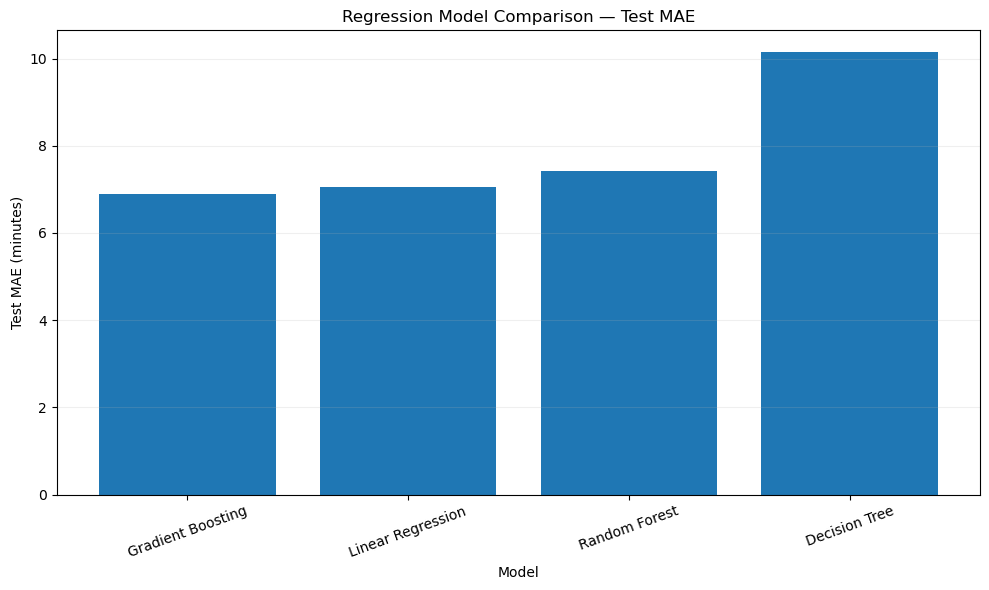

In [25]:
# ============================================================
# BLOCK 8 — MODEL COMPARISON
# TEST MAE
# ============================================================

chart_data = results_df.sort_values(
    "Test MAE"
)

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    chart_data["Model"],
    chart_data["Test MAE"]
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Test MAE (minutes)"
)

plt.title(
    "Regression Model Comparison — Test MAE"
)

plt.xticks(
    rotation=20
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

plt.show()

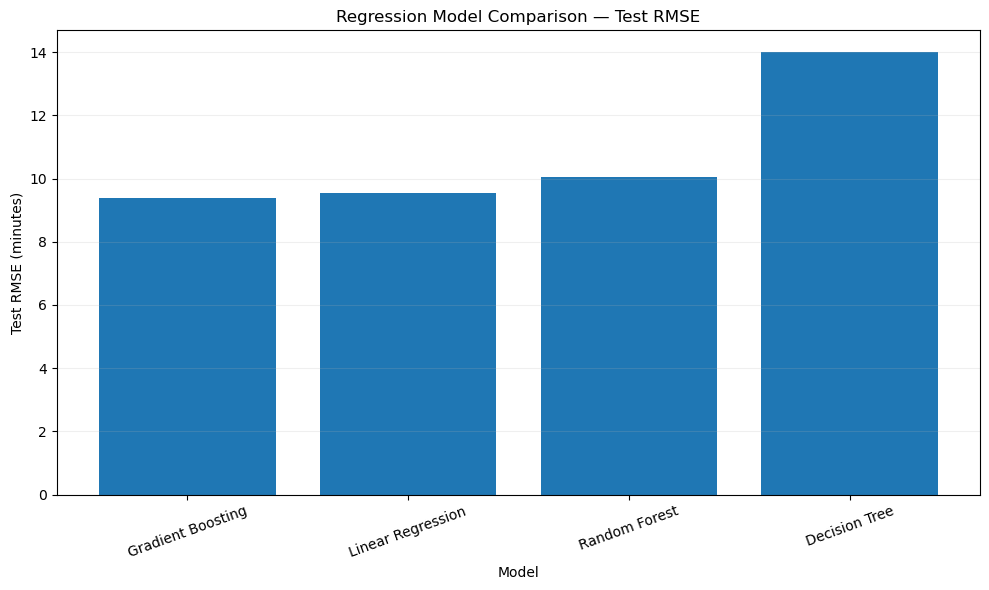

In [26]:
# ============================================================
# BLOCK 9 — MODEL COMPARISON
# TEST RMSE
# ============================================================

chart_data = results_df.sort_values(
    "Test RMSE"
)

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    chart_data["Model"],
    chart_data["Test RMSE"]
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Test RMSE (minutes)"
)

plt.title(
    "Regression Model Comparison — Test RMSE"
)

plt.xticks(
    rotation=20
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

plt.show()

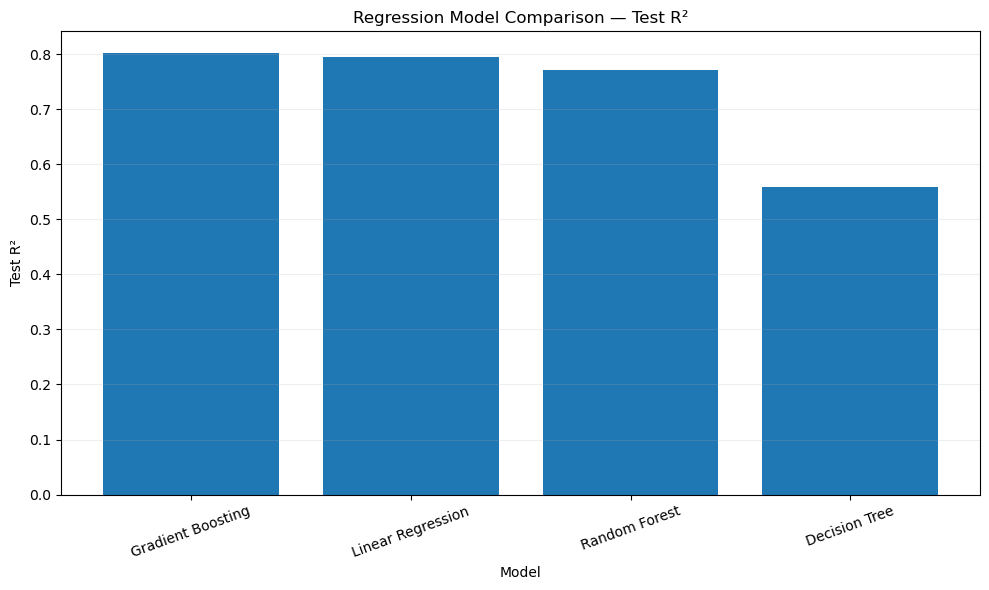

In [27]:
# ============================================================
# BLOCK 10 — MODEL COMPARISON
# TEST R²
# ============================================================

chart_data = results_df.sort_values(
    "Test R²",
    ascending=False
)

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    chart_data["Model"],
    chart_data["Test R²"]
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Test R²"
)

plt.title(
    "Regression Model Comparison — Test R²"
)

plt.xticks(
    rotation=20
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

plt.show()

In [28]:
# ============================================================
# BLOCK 11 — OVERFITTING CHECK
# ============================================================

overfitting_check = results_df[
    [
        "Model",
        "Train MAE",
        "Test MAE",
        "Train R²",
        "Test R²"
    ]
].copy()

overfitting_check["MAE_Gap"] = (
    overfitting_check["Test MAE"]
    - overfitting_check["Train MAE"]
)

overfitting_check["R²_Gap"] = (
    overfitting_check["Train R²"]
    - overfitting_check["Test R²"]
)

overfitting_check.round(3)

,Model,Train MAE,Test MAE,Train R²,Test R²,MAE_Gap,R²_Gap
0,Gradient Boosting,4.515,6.898,0.913,0.801,2.382,0.111
1,Linear Regression,6.891,7.065,0.782,0.795,0.174,-0.013
2,Random Forest,2.769,7.414,0.963,0.772,4.644,0.191
3,Decision Tree,0.000,10.141,1.000,0.559,10.141,0.441


In [29]:
# ============================================================
# BLOCK 12 — IDENTIFY TOP MODELS FOR HYPERPARAMETER TUNING
# ============================================================

top_models = (
    results_df
    .sort_values(
        "Test MAE"
    )
    .head(3)
)

print(
    "Top models based on Test MAE:"
)

print(
    top_models[
        [
            "Model",
            "Test MAE",
            "Test RMSE",
            "Test R²"
        ]
    ].round(3)
)

Top models based on Test MAE:
               Model  Test MAE  Test RMSE  Test R²
0  Gradient Boosting     6.898      9.386    0.801
1  Linear Regression     7.065      9.543    0.795
2      Random Forest     7.414     10.058    0.772


###### ------------------------------------------------------------------------------------------------------------ THE END ------------------------------------------------------------------------------------------------------------